# Phases block extraction and comparison

First step is to use and tweak Joshua's code to get the phase block instead of solution species block.

In [2]:
import warnings
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import build_database.clean_tables as ct
import build_database.utils as ut
import utils
import importlib.resources as pkg_resources
import build_database.parser_dat as parser_dat

ModuleNotFoundError: No module named 'parser_dat'

Josh had made a function for extracting different phases, so will check if this works alright.

In [ ]:
database_list = pkg_resources.files('build_database.databases')
database_list = ut.phreeqc_database_list(database_list)
phases = ct.compile_phase_table(database_list)
display(phases)


,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
0,(UO2)2As2O7,(UO2)2As2O7 +2H+ +H2O = + 2H2AsO4- + 2UO2+2,7.7066,"(-145.281, kJ/mol)","(-1.6147e+002, -6.3487e-002, 1.0052e+004, 6.23...",None,None,None,None,llnl.dat
1,(UO2)2Cl3,(UO2)2Cl3 = + UO2+ + UO2+2 + 3Cl-,12.7339,"(-140.866, kJ/mol)","(-2.3895e+002, -9.2925e-002, 1.1722e+004, 9.69...",None,None,None,None,llnl.dat
2,(UO2)2P2O7,(UO2)2P2O7 +H2O = + 2HPO4-2 + 2UO2+2,-14.6827,"(-103.726, kJ/mol)","(-3.4581e+002, -1.3987e-001, 1.0703e+004, 1.36...",None,None,None,None,llnl.dat
3,(UO2)3(AsO4)2,(UO2)3(AsO4)2 +4H+ = + 2H2AsO4- + 3UO2+2,9.3177,"(-186.72, kJ/mol)","(-1.9693e+002, -7.3236e-002, 1.2936e+004, 7.46...",None,None,None,None,llnl.dat
4,(UO2)3(PO4)2,(UO2)3(PO4)2 +2H+ = + 2HPO4-2 + 3UO2+2,-14.0241,"(-149.864, kJ/mol)","(-3.6664e+002, -1.4347e-001, 1.3486e+004, 1.41...",None,None,None,None,llnl.dat
...,...,...,...,...,...,...,...,...,...,...
2741,HCl(g),HCl = 1H+ + 1Cl-,6.29,"(-74.770,)","(-6.80912E+0, 0E+0, 3.9055E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat
2742,O2(g),O2 = 1O2,-2.9,"(-12.134,)","(-5.02578E+0, 0E+0, 6.33802E+2, 0E+0, 0E+0)",None,None,None,None,sit.dat
2743,SO2(g),SO2 = 2H+ + 1SO3-2 - 1H2O,-8.94,"(-48.420,)","(-1.74228E+1, 0E+0, 2.52915E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat
2744,H2O(g),Ca(UO2)2(SiO3OH)2 + 6H+ = Ca+2 + 2UO2+2 + 2H4SiO4,17.489,"(-11.0, kcal)","(-0.26, 0.0, -731.0, 0.0, 0.0)",None,None,None,None,Tipping_Hurley.dat


Let's check which source has the most data

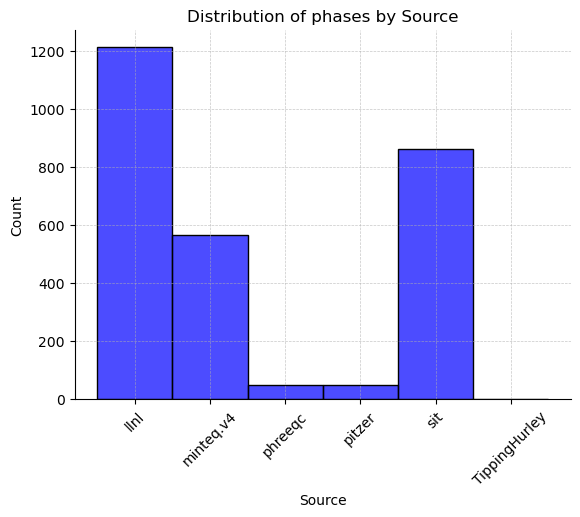

In [ ]:
utils.plot_source_hist(phases,'Distribution of phases by Source')

This means that llnl has the most number of phases according to his code. Now, the code itself seems okay, so I tested it one by one if it contains all the phases in each database file.

In [ ]:
# checking how many phases llnl has
phases_llnl = phases[phases['source'].str.contains('llnl')]
display(phases_llnl)
#llnl contains 1214 phases according to this.

,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
0,(UO2)2As2O7,(UO2)2As2O7 +2H+ +H2O = + 2H2AsO4- + 2UO2+2,7.7066,"(-145.281, kJ/mol)","(-1.6147e+002, -6.3487e-002, 1.0052e+004, 6.23...",None,None,None,None,llnl.dat
1,(UO2)2Cl3,(UO2)2Cl3 = + UO2+ + UO2+2 + 3Cl-,12.7339,"(-140.866, kJ/mol)","(-2.3895e+002, -9.2925e-002, 1.1722e+004, 9.69...",None,None,None,None,llnl.dat
2,(UO2)2P2O7,(UO2)2P2O7 +H2O = + 2HPO4-2 + 2UO2+2,-14.6827,"(-103.726, kJ/mol)","(-3.4581e+002, -1.3987e-001, 1.0703e+004, 1.36...",None,None,None,None,llnl.dat
3,(UO2)3(AsO4)2,(UO2)3(AsO4)2 +4H+ = + 2H2AsO4- + 3UO2+2,9.3177,"(-186.72, kJ/mol)","(-1.9693e+002, -7.3236e-002, 1.2936e+004, 7.46...",None,None,None,None,llnl.dat
4,(UO2)3(PO4)2,(UO2)3(PO4)2 +2H+ = + 2HPO4-2 + 3UO2+2,-14.0241,"(-149.864, kJ/mol)","(-3.6664e+002, -1.4347e-001, 1.3486e+004, 1.41...",None,None,None,None,llnl.dat
...,...,...,...,...,...,...,...,...,...,...
1209,UOF4(g),UOF4 +H2O = + UO2+2 + 2H+ + 4F-,24.2848,"(-312.552, kJ/mol)","(-3.9592e+002, -1.3699e-001, 2.4127e+004, 1.53...",None,None,None,None,llnl.dat
1210,Xe(g),Xe = + Xe,-2.364,"(-18.8698, kJ/mol)","(-2.0636e+001, 5.1389e-003, 2.0490e+002, 5.191...",None,None,None,None,llnl.dat
1211,Zn(g),Zn +2H+ +0.5000 O2 = + H2O + Zn+2,85.414,"(-563.557, kJ/mol)","(-1.0898e+001, -3.9871e-003, 2.9068e+004, 0.00...",None,None,None,None,llnl.dat
1212,Zr(g),Zr +4H+ +O2 = + Zr+4 + 2H2O,277.1324,"(0,)",None,None,None,None,None,llnl.dat


In [ ]:
#So I copied and pasted whole 'phases' section from llnl and made a simple code to count the lines that don't start with # or a tab.
phasefile = open("llnl_phase.txt","r")
outputphase = open("llnl_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()
# the result showed that there are 1215 phases in phases block, which is not good, since we only have 1214 in josh's code...

Okay, so I will check if phases 'missed' one, or sensed the wrong 'duplicates'. If it missed one, there should be something printed underneath the python shell. If not, Josh's code accidentally deemed something 'duplicates' that weren't duplicate.

In [ ]:
outputphase = open("llnl_phasename.txt",'r')
all_lines = outputphase.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i].strip()
    line_clean = line.strip()
    name_clean = phases_llnl['phase_name'].str.strip()
    name_clean.to_csv("phase_names.txt", index=False, header=False)


    if not (name_clean == line_clean).any():
        print(line)

outputphase.close()

Na


So it seems Josh missed the Na block:

Na

       Na +1.0000 H+ +0.2500 O2  =  + 0.5000 H2O + 1.0000 Na+
        log_k           67.3804
	-delta_H	-380.185	kJ/mol	# Calculated enthalpy of reaction	Na
	Enthalpy of formation:	0 kJ/mol
        -analytic -4.0458e+001 -8.7899e-003 2.1223e+004 1.5927e+001 -1.2715e+004
       -Range:  0-300

So based on this, let's change his code a little bit and test it again.